# Regression Using Tensorflow and Deep Learning

- Input layer shape
- Hidden layer(s)
- Neurons per hidden..layer
- Output layer shape
- Hidden activation
- output activation
- loss function
- optimizer

In [1]:
import tensorflow as tf
print(tf.__version__)

2.20.0


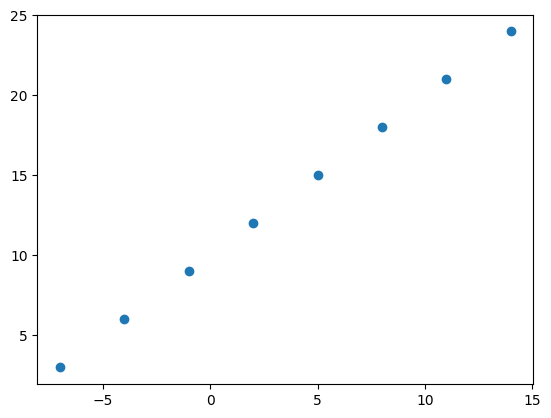

In [2]:
import numpy as np
import matplotlib.pyplot as plt

X = tf.constant(np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0]))
y = tf.constant(np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0]))

plt.scatter(X, y)

In [3]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape # Output is ((), ()) because the dimention is 0, scalar tensors

(TensorShape([]), TensorShape([]))

## Steps in modeling with tensorflow


In [4]:
tf.random.set_seed(42)


# 1. Create a model using the sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. compile the model
model.compile(loss=tf.keras.losses.mae, optimizer=tf.keras.optimizers.SGD(), metrics=['mae'])

# Reshape X to be compatible with the Dense layer (add an extra dimension)
X_reshaped = tf.expand_dims(X, axis=-1)

# 3. Fit the model
model.fit(X_reshaped, y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 14.5563 - mae: 14.5563
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 14.4238 - mae: 14.4238
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - loss: 14.2913 - mae: 14.2913
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 14.1588 - mae: 14.1588
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 14.0263 - mae: 14.0263


In [5]:
# Making prediction
model.predict(tf.expand_dims(tf.constant([17.0]), axis=-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


array([[-2.1056511]], dtype=float32)

## Improving the model

we can improve our model, by altering the steps we took to create a model.
1. **Creating a model** - add more layers, increase the number of hidden units (all called neurons) within each of the hidden layers, change activation functions of each layer
2. **Compiling a model**: here we might change the opimization function or perhaps the learning rate
3. **Fitting a model**: increase the number of epochs


### Improvement 1

In [6]:
# 1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
], name="Model_1")

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae'])

# 3. Fit the model
model.fit(X_reshaped, y, epochs=100, verbose=0) # what does verbose does, different modes

In [7]:
model.predict(tf.expand_dims(tf.constant([17.0]), axis=-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


array([[29.269524]], dtype=float32)

### Improvement 2


What does each Dense mean, tf.keras.layers.Dense mean, and its parameters mean

In [8]:
# Create Model
model1 = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation=None, input_shape=[1], name='input_layer'), # Correct input_shape to match X's features
    # tf.keras.layers.Dense(100, activation='relu'),
    # tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(1, input_shape=[1], name='output_layer') # Removed redundant input_shape from subsequent Dense layer
], name='model_2') # 'model_2' is a valid name, the issue was likely with a historical prefix

# Compile the model
model1.compile(loss=tf.keras.losses.mae,
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
               metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model1.summary()

Model: "model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

- What are total params? - total number of parameters in the model
- Trainable params: the parameters that the model can update
- non-tranable params: freeze model data like in the, this parameters are not updated during training. transfer learning

Resource: MIT intro to Deep Learning


In [10]:
model1.fit(X, y, epochs=100, verbose=0)

In [11]:
data = tf.expand_dims([17.0], axis=-1)
model1.predict(data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([[27.465096]], dtype=float32)

The matrices that we are seeing while training might not be representative of the actual learning of the model

If add more neurons (layers) or epoches don't improve our model what does? how to know better what does and what does not?

Learning rate is the most imporatnt

More about adjusting Hyperparameters


In [12]:
X = tf.range(-100, 100, 4)
y = X + 10
y = tf.cast(y, dtype=tf.float32)


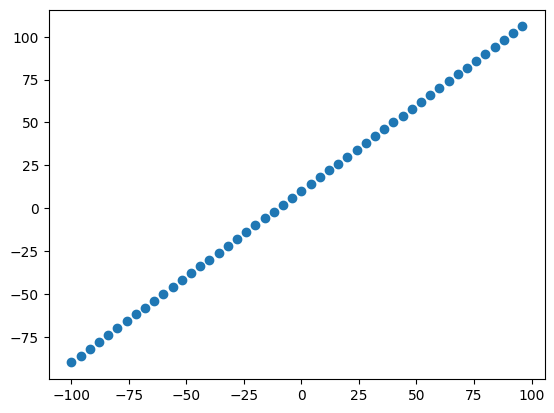

In [13]:
plt.scatter(X, y)

## The 3 Sets
- Training Set
- Validation Set
- Test Set

In [41]:
len(X)


X_train = X[:40]
y_train = y[:40]

X_test = X[40:]
y_test = y[40:]

X_train, y_train, X_test, y_test

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56], dtype=int32)>,
 <tf.Tensor: shape=(40,), dtype=float32, numpy=
 array([-90., -86., -82., -78., -74., -70., -66., -62., -58., -54., -50.,
        -46., -42., -38., -34., -30., -26., -22., -18., -14., -10.,  -6.,
         -2.,   2.,   6.,  10.,  14.,  18.,  22.,  26.,  30.,  34.,  38.,
         42.,  46.,  50.,  54.,  58.,  62.,  66.], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([60, 64, 68, 72, 76, 80, 84, 88, 92, 96], dtype=int32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 70.,  74.,  78.,  82.,  86.,  90.,  94.,  98., 102., 106.],
       dtype=float32)>)

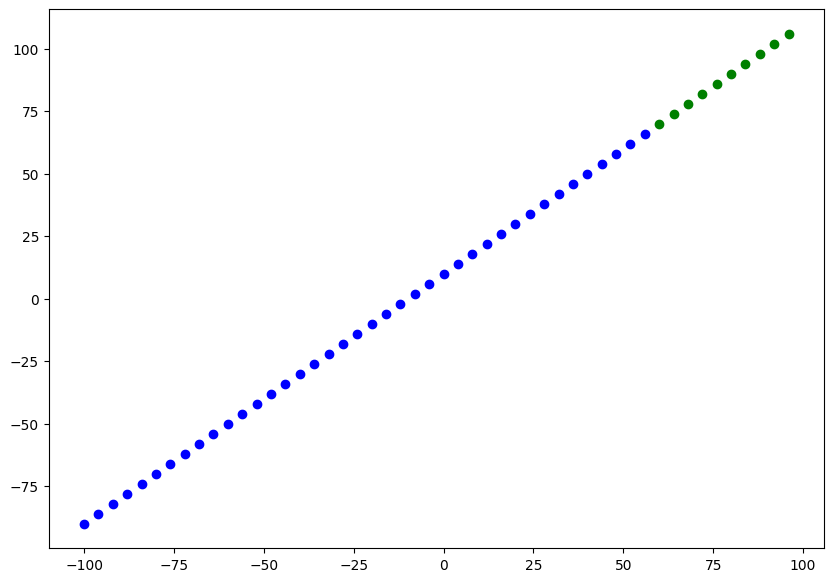

In [42]:
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, c='blue', label="Training Data")
plt.scatter(X_test, y_test, c='green', label="Testing Data")

In [16]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1], name='layer_1'),
    tf.keras.layers.Dense(1, name='layer_2')
])

model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=['mae'])

model.fit(X_train, y_train, epochs=100, verbose=0)

Create a model which builds automatically by defining the input_shape argument in the first layer, how to define the input shape?

what does the verbose, fit argument does

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer_1 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

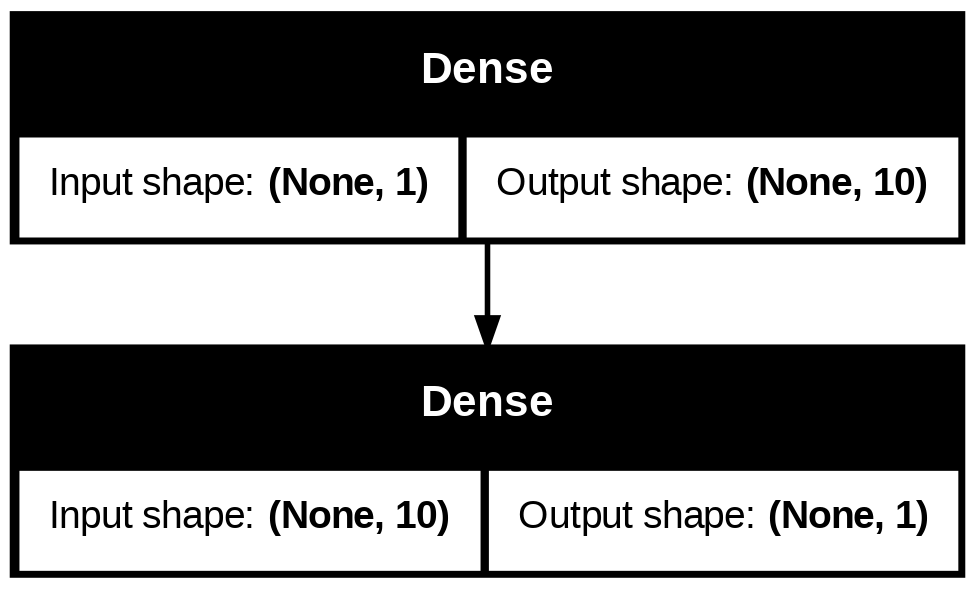

In [18]:
from tensorflow.keras.utils import plot_model # what does plot model do
plot_model(model, show_shapes=True)

### Visualizing Model Predictions

- `y_true` vs `y_pred`

In [19]:
y_pred = model.predict(X_test)

y_pred = tf.squeeze(y_pred)

y_pred, y_test, abs(y_pred - y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 68.945496,  72.87411 ,  76.80272 ,  80.73133 ,  84.65994 ,
         88.58856 ,  92.517166,  96.44578 , 100.3744  , 104.303   ],
       dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 70.,  74.,  78.,  82.,  86.,  90.,  94.,  98., 102., 106.],
       dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([1.0545044, 1.1258926, 1.1972809, 1.2686691, 1.3400574, 1.411438 ,
        1.4828339, 1.5542221, 1.6256027, 1.6969986], dtype=float32)>)

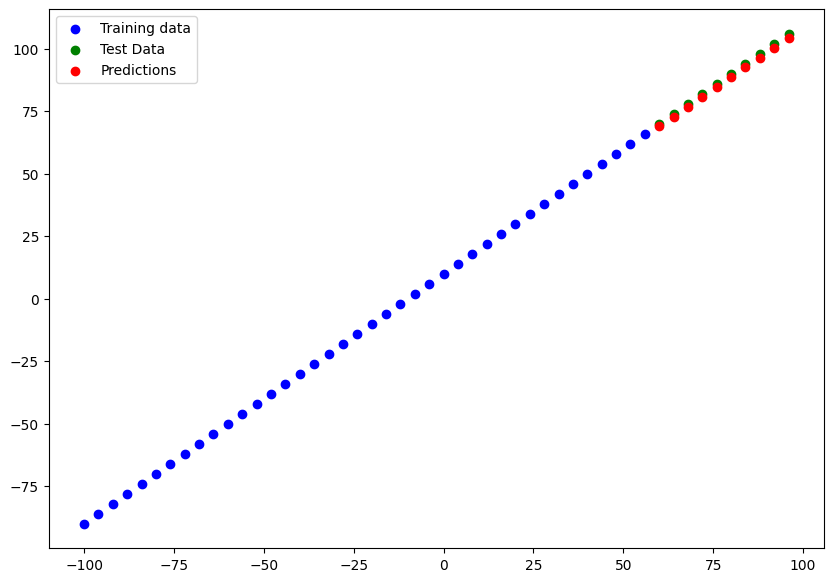

In [20]:
# Plotting Function
def plot_predictions(train_data =X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=y_pred):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="blue", label="Training data")
  # Plot test data in green
  plt.scatter(test_data, test_labels, c='green', label='Test Data')
  # Plot the predictions in red (predictions were made on the test data)
  plt.scatter(test_data, predictions, c='red', label='Predictions')
  # Show the legend
  plt.legend()
  plt.show()

plot_predictions()


## Evaluating a Models predictions

In [21]:
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 1.3757 - mae: 1.3757


[1.375749945640564, 1.375749945640564]

In [58]:
def evaluate(model, X_test, y_test):
  """
  Given model and test X and Y, it calculates MAE, MSE and HUBER loss and returns a tuple in that order
  """
  y_pred = model.predict(X_test)
  y_pred = tf.squeeze(y_pred)
  mae = tf.metrics.mae(y_test, y_pred)
  mse = tf.metrics.mse(y_test, y_pred)
  huber = tf.metrics.huber(y_test, y_pred)

  print(f"MAE: {mae.numpy()}")
  print(f"MSE: {mse.numpy()}")
  print(f"Huber: {huber.numpy()}")
  return (mae, mse, huber)
evaluate(model, X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
MAE: 1.375749945640564
MSE: 1.9347318410873413
Huber: 0.875749945640564


(<tf.Tensor: shape=(), dtype=float32, numpy=1.375749945640564>,
 <tf.Tensor: shape=(), dtype=float32, numpy=1.9347318410873413>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.875749945640564>)

## Running Experiments to improve our model

1. Get more data
2. Make model larger - add more layers, more hidden layers
3. Train for longer - give model more of a change to find patterns in data

Let's do 3 modelling experiments:
1. `model_1` - same as the origial model, 1 layer, trained for 100 epochs
2. `model_2` - 2 layers, trained for 100 epochs
3. `model_3` - 2 layers, trained for 500 epochs

In [43]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])
])

model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

model_1.fit(X_train, y_train, epochs=100, verbose=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


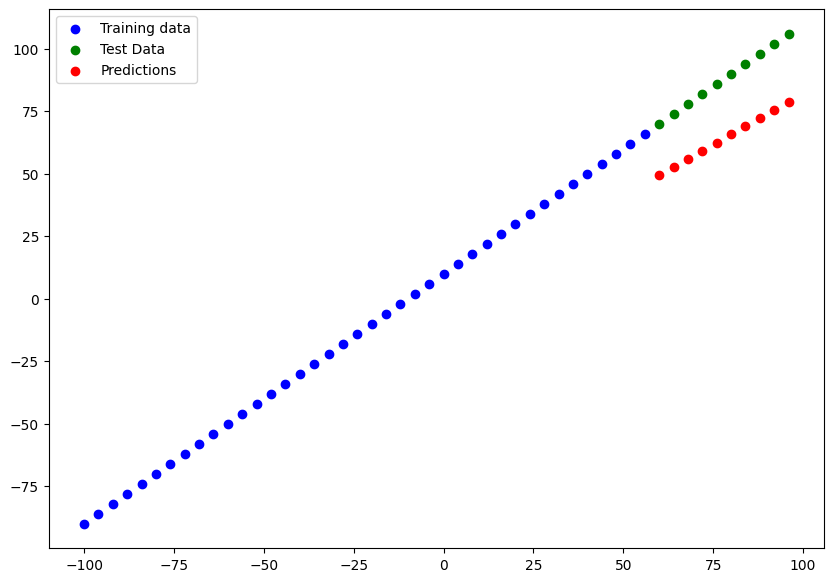

In [44]:
preds_1 = model_1.predict(X_test)
preds_1 = tf.squeeze(preds_1)

plot_predictions(predictions=preds_1)

In [61]:
mae_1, mse_1, huber_1 = evaluate(model_1, X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
MAE: 23.88323211669922
MSE: 575.4757080078125
Huber: 23.38323211669922


In [52]:
# Model 2
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, input_shape=[1]),
    tf.keras.layers.Dense(1)
])

model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mse'])

model_2.fit(X_train, y_train, epochs=100, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


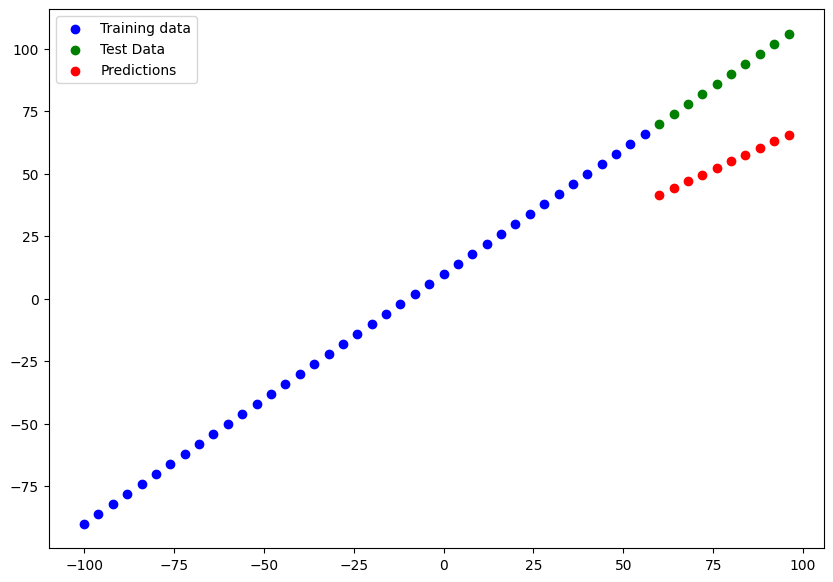

In [47]:
preds_2 = model_2.predict(X_test)
plot_predictions(predictions=preds_2)

In [60]:
mae_2, mse_2, huber_2 = evaluate(model_2, X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
MAE: 28.204914093017578
MSE: 804.1009521484375
Huber: 27.704914093017578


In [53]:
# Model 3

tf.random.set_seed(42)

model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, input_shape=[1]),
    tf.keras.layers.Dense(1)
])

model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

model_3.fit(X_train, y_train, epochs=500, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


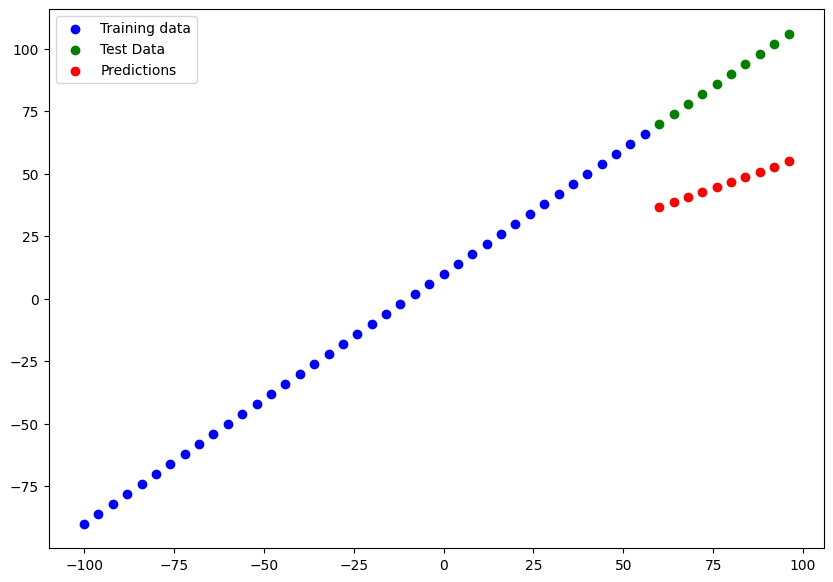

In [50]:
plot_predictions(predictions=model_3.predict(X_test))

In [59]:
mae_3, mse_3, huber_3 = evaluate(model_3, X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
MAE: 39.17715072631836
MSE: 1561.9830322265625
Huber: 38.67715072631836


## Comparing Result of Experiments



In [ ]:
# Lets Compare our model's results using a pandas DataFrame
import pandas as pd

model_results = [
    ["model_1", mae_1, mse_1],
    ["model_2", mae_2, mse_2],
    ["model_3", mae_3, mse_3]
]

all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results